# v4 substrate replay — Layer 2 diagnostics

Reads dial inputs off the current v3 labelled pool (tier-0 native non-waste) to pin the open dials in §9 of the v4 plan:

1. Feasibility census — cap_B(s) versus f_s at ρ ∈ {0.5, 0.8, 1.0, 1.5}.
2. Family concentration — refute or confirm the 91% one-template claim.
3. Novelty attrition — survival at θ₀ ∈ {0.3, 0.5, 0.7}.
4. Lane-yield sanity — per-lane ŷ_c(l) across 39 live lanes.

**Not** a v3-vs-v4 outcome comparison — v3 was composed under different rules and any output-side delta is confounded.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown

from composition.pool_v3 import LabelledPool, STRATA, CLASSES
from composition.objectives import SelectionOrder
from composition.recipe import Recipe

recipe = Recipe.v3()
pool_owner = LabelledPool(recipe)
pool = pool_owner.frame()
sel = pool_owner.selectable()
P = sel[~sel['is_waste']]
cells = pool_owner.active_cells()
cell_names = [c.name for c in cells]
N_star = recipe.target_total
kappa = recipe.target_lane_share
kN = math.ceil(kappa * N_star)
print(f'P (tier-0 non-waste native): {len(P):,} rows, {P["dataset"].nunique()} live lanes, {len(cells)} active cells')
print(f'N* = {N_star:,}, kappa = {kappa}, ceil(kappa*N*) = {kN:,}')

/Users/andrei/projects/hybrid-search-rrf-dataset/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


P (tier-0 non-waste native): 77,802 rows, 39 live lanes, 63 active cells
N* = 200,000, kappa = 0.2, ceil(kappa*N*) = 40,000


## 1. Feasibility census

For each axis and each ρ, count strata whose `cap_B(s) = Σ_l min(|P_{s,l}|, ⌈κ·N*⌉)` reaches `f_s = max(25, ρ·N*/|S_a|)`. The rest is generation debt.

In [2]:
def membership(P, axis):
    if axis == 'cell':
        return {c.name: P['cells'].map(lambda s, n=c.name: n in s) for c in cells}
    return {b: (P[axis] == b) for b in STRATA[axis]}

AXES = ['cell', 'corruption_degree', 'corpus_idf', 'corpus_oov', 'corpus_pmi']
RHOS = [0.5, 0.8, 1.0, 1.5]

def cap_B(P, mask):
    per_lane = P.loc[mask].groupby('dataset').size()
    return int(np.minimum(per_lane.to_numpy(), kN).sum())

rows = []
for axis in AXES:
    memb = membership(P, axis)
    S_a = len(memb)
    caps = {s: cap_B(P, m) for s, m in memb.items()}
    for rho in RHOS:
        f_s = max(25, round(rho * N_star / S_a))
        reached = sum(1 for c in caps.values() if c >= f_s)
        rows.append({
            'axis': axis, '|S_a|': S_a, 'rho': rho, 'f_s': f_s,
            'reached': reached, 'debt_strata': S_a - reached,
            'S_r_share': round(reached / S_a, 3),
        })
cap_summary = pd.DataFrame(rows)
cap_summary

,axis,|S_a|,rho,f_s,reached,debt_strata,S_r_share
0,cell,63,0.5,1587,12,51,0.190
1,cell,63,0.8,2540,9,54,0.143
2,cell,63,1.0,3175,9,54,0.143
3,cell,63,1.5,4762,8,55,0.127
4,corruption_degree,3,0.5,33333,1,2,0.333
5,corruption_degree,3,0.8,53333,1,2,0.333
6,corruption_degree,3,1.0,66667,1,2,0.333
7,corruption_degree,3,1.5,100000,0,3,0.000
8,corpus_idf,3,0.5,33333,1,2,0.333
9,corpus_idf,3,0.8,53333,0,3,0.000


In [3]:
# per-stratum caps at rho=1.0 — where the debt lives
detail = []
for axis in AXES:
    memb = membership(P, axis)
    S_a = len(memb)
    f_s_10 = max(25, round(1.0 * N_star / S_a))
    for s, m in memb.items():
        cap = cap_B(P, m)
        detail.append({
            'axis': axis, 'stratum': s, 'pool_rows': int(m.sum()),
            'cap_B(rho=1.0)': cap, 'f_s(rho=1.0)': f_s_10,
            'reached': cap >= f_s_10,
        })
cap_detail = pd.DataFrame(detail).sort_values(['axis', 'cap_B(rho=1.0)'])
print('debt strata at rho=1.0:')
cap_detail[~cap_detail['reached']].head(20)

debt strata at rho=1.0:


,axis,stratum,pool_rows,cap_B(rho=1.0),f_s(rho=1.0),reached
17,cell,symbol_pile_no_grammar,0,0,3175,False
21,cell,datetime_token_present,0,0,3175,False
23,cell,status_code_idf_split,0,0,3175,False
24,cell,rare_key_buried_in_chatter,0,0,3175,False
25,cell,bare_number_token,0,0,3175,False
27,cell,short_quantified_spec,0,0,3175,False
30,cell,bare_machine_token,0,0,3175,False
31,cell,registry_structured_identifier,0,0,3175,False
32,cell,logistics_catalog_token,0,0,3175,False
33,cell,legal_citation_canonical,0,0,3175,False


## 2. Family concentration

Checks the plan's `lane_synthesize` = 91% claim and the effective family count over the pool. Both `augmentation/pool.parquet` (operator level) and `LabelledPool.family_ids` (parent query id) are reported.

In [4]:
from composition.pool_v3 import DATA
aug_path = DATA / 'augmentation' / 'pool.parquet'
if aug_path.exists():
    aug = pd.read_parquet(aug_path, columns=['operator'])
    op_counts = aug['operator'].value_counts()
    op_share = op_counts / len(aug)
    ls_share = float(op_share.get('lane_synthesize', 0.0))
    print(f'augmentation pool rows: {len(aug):,}')
    print(f'lane_synthesize share: {ls_share:.3f}  (plan says 0.91)')
    print(op_share.round(4).to_string())
else:
    print('augmentation/pool.parquet missing — skipped')
    ls_share = None

augmentation pool rows: 112,263
lane_synthesize share: 0.910  (plan says 0.91)
operator
lane_synthesize            0.9104
corrupt                    0.0582
decorate                   0.0156
inject                     0.0083
stat_rewrite               0.0050
synthesize                 0.0018
operator_syntax_rewrite    0.0007


In [5]:
fam = pool_owner.family_ids(P)
fam_counts = fam.value_counts()
freq = fam_counts.to_numpy() / fam_counts.sum()
H = -(freq * np.log(freq)).sum()
eff_families = float(np.exp(H))
print(f'rows: {len(P):,}  distinct families: {len(fam_counts):,}  eff (exp H): {eff_families:,.1f}')
print(f'top-1 family share: {freq[0]:.5f}   top-20 share: {freq[:20].sum():.5f}')
fam_counts.head(20).to_frame('rows')

rows: 77,802  distinct families: 72,697  eff (exp H): 71,031.6
top-1 family share: 0.00004   top-20 share: 0.00067


,rows
beir-nfcorpus:PLAIN-112,3
crumb-clinical-trial:2021-34,3
crumb-clinical-trial:2021-53,3
crumb-clinical-trial:2022-16,3
rarb-math:MATH-q-549,3
rarb-math:MATH-q-4170,3
rarb-code:mbpp-q-316,3
beir-nfcorpus:PLAIN-2860,3
crumb-legal-qa:2911,3
rarb-code:mbpp-q-345,3


## 3. Novelty attrition

For each stratum with pool ≥ 25, sample a seed (20 rows) and up to 500 candidates, compute `N(q|D_seed) = 1 − max_x J(q,x)` on whitespace tokens, and report survival at θ₀ ∈ {0.3, 0.5, 0.7}. Estimated survivors = `|P_s| · survival_rate`. Cross-lane by convenience — a rough diagnostic; per-lane novelty is what the algorithm actually uses.

In [6]:
def tok(text):
    return frozenset(str(text).lower().split())

def survival_rates(tokens, seed_ix, cand_ix, thetas):
    seed = [tokens[i] for i in seed_ix]
    out = {t: 0 for t in thetas}
    for i in cand_ix:
        q = tokens[i]
        if not q:
            continue
        best = 0.0
        for s in seed:
            union = q | s
            if not union:
                continue
            j = len(q & s) / len(union)
            if j > best:
                best = j
        nov = 1.0 - best
        for t in thetas:
            if nov >= t:
                out[t] += 1
    n = max(len(cand_ix), 1)
    return {t: out[t] / n for t in thetas}

rng = np.random.default_rng(0)
THETAS = [0.3, 0.5, 0.7]
SEED_N, MAX_CAND = 20, 500

rows = []
for axis in AXES:
    memb = membership(P, axis)
    S_a = len(memb)
    f_s = max(25, round(1.0 * N_star / S_a))
    for s, m in memb.items():
        pool_s = P.loc[m]
        n_s = len(pool_s)
        if n_s < SEED_N + 25:
            rows.append({
                'axis': axis, 'stratum': s, 'pool_rows': n_s,
                'f_s': f_s, **{f'surv_{t}': None for t in THETAS},
                **{f'est_survivors_{t}': None for t in THETAS},
            })
            continue
        take = pool_s.sample(n=min(SEED_N + MAX_CAND, n_s),
                             random_state=int(rng.integers(2**31)))
        tokens = [tok(q) for q in take['query'].tolist()]
        seed_ix = list(range(SEED_N))
        cand_ix = list(range(SEED_N, len(take)))
        sr = survival_rates(tokens, seed_ix, cand_ix, THETAS)
        rows.append({
            'axis': axis, 'stratum': s, 'pool_rows': n_s, 'f_s': f_s,
            **{f'surv_{t}': round(sr[t], 3) for t in THETAS},
            **{f'est_survivors_{t}': int(round(sr[t] * n_s)) for t in THETAS},
        })
nov = pd.DataFrame(rows)
nov.head(20)

,axis,stratum,pool_rows,f_s,surv_0.3,surv_0.5,surv_0.7,est_survivors_0.3,est_survivors_0.5,est_survivors_0.7
0,cell,bare_concept_token,4,3175,NaN,NaN,NaN,NaN,NaN,NaN
1,cell,short_grammatical_question,15,3175,NaN,NaN,NaN,NaN,NaN,NaN
2,cell,stopword_saturated_midlength,615,3175,0.836,0.668,0.438,514.0,411.0,269.0
3,cell,verbose_grammatical_request,4709,3175,0.924,0.894,0.842,4351.0,4210.0,3965.0
4,cell,extreme_length_pasted_query,1588,3175,0.972,0.972,0.954,1544.0,1544.0,1515.0
5,cell,high_morphological_variation,741,3175,0.998,0.992,0.726,740.0,735.0,538.0
6,cell,deep_nesting_single_sentence,5006,3175,1.000,1.000,0.952,5006.0,5006.0,4766.0
7,cell,multi_statement_context_dump,6591,3175,0.966,0.894,0.864,6367.0,5892.0,5695.0
8,cell,wide_flat_enumeration,2010,3175,0.996,0.994,0.972,2002.0,1998.0,1954.0
9,cell,keyword_telegram_short,31,3175,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Two questions: (a) median attrition; (b) does theta drop a FEASIBLE stratum?
# 'feasible' = cap_B(rho=1.0) >= f_s at rho=1.0 — the reachable set S^r.
cap_key = cap_detail.set_index(['axis', 'stratum'])
nov_j = nov.merge(cap_key[['cap_B(rho=1.0)']],
                  left_on=['axis', 'stratum'], right_index=True)
feasible = nov_j[nov_j['cap_B(rho=1.0)'] >= nov_j['f_s']]
print(f'reachable strata (rho=1.0, any axis): {len(feasible)}')
for t in THETAS:
    col = f'est_survivors_{t}'
    survcol = f'surv_{t}'
    all_measured = nov_j[nov_j[survcol].notna()]
    med = all_measured[survcol].median()
    feas_measured = feasible[feasible[survcol].notna()]
    dropped = feas_measured[feas_measured[col] < feas_measured['f_s']]
    print(f'theta0={t}: median survival {med:.3f}; '
          f'{len(dropped)}/{len(feas_measured)} reachable strata drop below f_s')
print()
print('reachable strata that theta=0.7 pushes below f_s:')
reach_break = feasible[feasible['surv_0.7'].notna() &
                       (feasible['est_survivors_0.7'] < feasible['f_s'])]
reach_break[['axis', 'stratum', 'pool_rows', 'cap_B(rho=1.0)', 'f_s',
             'surv_0.7', 'est_survivors_0.7']]

reachable strata (rho=1.0, any axis): 10
theta0=0.3: median survival 0.998; 0/10 reachable strata drop below f_s
theta0=0.5: median survival 0.992; 0/10 reachable strata drop below f_s
theta0=0.7: median survival 0.949; 0/10 reachable strata drop below f_s

reachable strata that theta=0.7 pushes below f_s:


,axis,stratum,pool_rows,cap_B(rho=1.0),f_s,surv_0.7,est_survivors_0.7


## 4. Lane-yield sanity

`SelectionOrder.yields(pool)` reports per-lane class yields off blind rows only (reused rows entered on outcome and estimate nothing).

In [8]:
y = SelectionOrder.yields(pool)
lanes = y.sort_values('yield_hybrid', ascending=False)
print(f'lanes: {len(lanes)}, blind rows total: {int(lanes["blind_labelled"].sum()):,}')
lanes.round(4)

lanes: 41, blind rows total: 223,711


,blind_labelled,yield_dense,yield_sparse,yield_hybrid
dataset,,,,
miracl-en-dev,870,0.1529,0.0724,0.5448
crumb-paper-retrieval,107,0.4299,0.2150,0.3551
dbpedia-entity,483,0.3520,0.2671,0.3478
lotte-technology-search,664,0.4563,0.0828,0.3178
beir-nfcorpus,189,0.3228,0.1323,0.2751
lotte-technology-forum,2364,0.4839,0.1713,0.2403
bright-robotics,126,0.1349,0.2937,0.2302
quest,47228,0.1139,0.2009,0.1976
crumb-set-operation-entity-retrieval,6680,0.1178,0.1936,0.1924


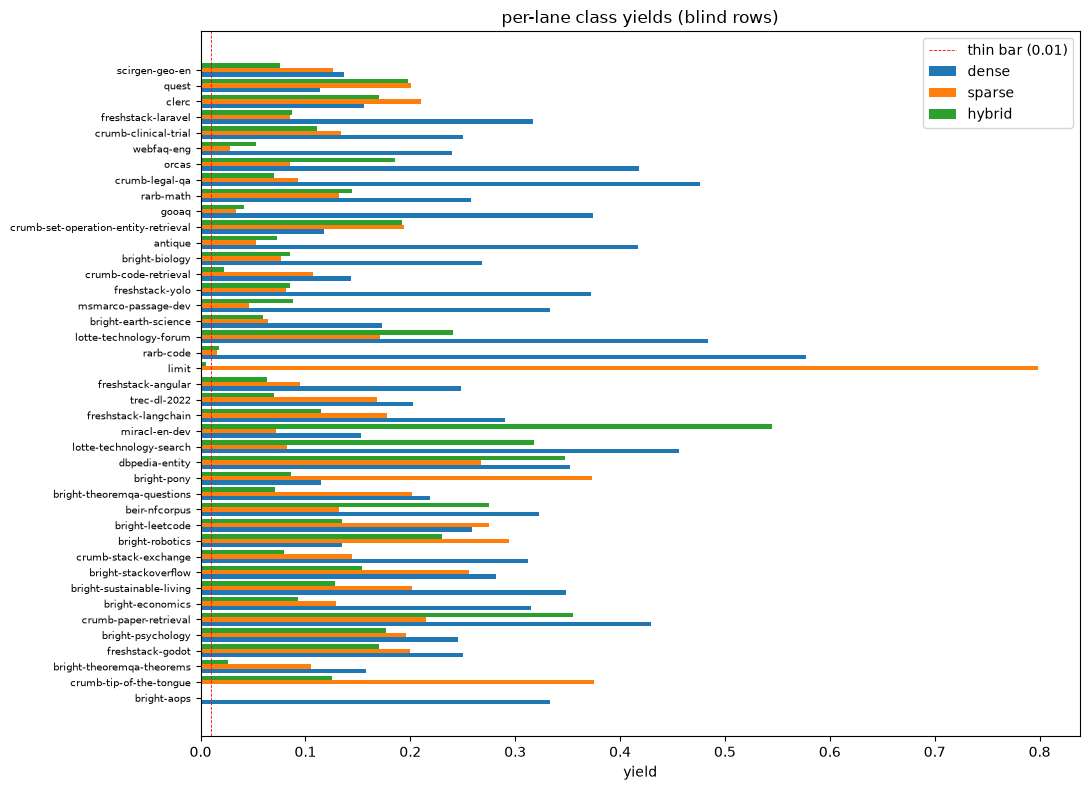

In [9]:
fig, ax = plt.subplots(figsize=(11, 8))
y_sorted = y.sort_values('blind_labelled', ascending=True)
idx = np.arange(len(y_sorted))
w = 0.28
ax.barh(idx - w, y_sorted['yield_dense'], w, label='dense', color='tab:blue')
ax.barh(idx,     y_sorted['yield_sparse'], w, label='sparse', color='tab:orange')
ax.barh(idx + w, y_sorted['yield_hybrid'], w, label='hybrid', color='tab:green')
ax.set_yticks(idx); ax.set_yticklabels(y_sorted.index, fontsize=7)
ax.axvline(0.01, color='red', linestyle='--', linewidth=0.6,
           label='thin bar (0.01)')
ax.set_xlabel('yield')
ax.set_title('per-lane class yields (blind rows)')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
thin = []
for lane in y.index:
    n = int(y.at[lane, 'blind_labelled'])
    if n < 50:
        continue
    for c in CLASSES:
        val = float(y.at[lane, f'yield_{c}'])
        if val < 0.01:
            thin.append({'lane': lane, 'class': c, 'yield': val,
                         'blind_labelled': n})
thin_df = pd.DataFrame(thin).sort_values(['class', 'yield'])
print(f'thin (yield<0.01 at n>=50): {len(thin_df)} lane-class cells')
thin_df

thin (yield<0.01 at n>=50): 2 lane-class cells


,lane,class,yield,blind_labelled
0,limit,dense,0.00000,1420
1,limit,hybrid,0.00493,1420


## Findings

In [11]:
cells_row = cap_summary.query('axis=="cell" and rho==1.0').iloc[0]
small_axis_row = cap_summary.query('axis=="corruption_degree" and rho==1.0').iloc[0]

op_line = (f'lane_synthesize = {ls_share:.1%} of augmentation pool '
           if ls_share is not None else 'augmentation pool missing; ')

theta_lines = []
for t in THETAS:
    survcol, escol = f'surv_{t}', f'est_survivors_{t}'
    all_measured = nov_j[nov_j[survcol].notna()]
    feas_measured = feasible[feasible[survcol].notna()]
    dropped = feas_measured[feas_measured[escol] < feas_measured['f_s']]
    theta_lines.append(
        f'theta={t}: median stratum survival '
        f'{all_measured[survcol].median():.2f}, '
        f'{len(dropped)}/{len(feas_measured)} reachable strata '
        'pushed below f_s'
    )

text = (
    '### Findings\n\n'
    '**Feasibility (rho).** cells is the binding axis: at rho=1.0 only '
    f'{int(cells_row["reached"])}/{int(cells_row["|S_a|"])} '
    f'({cells_row["S_r_share"]:.0%}) of the 63 cells reach '
    f'f_s={int(cells_row["f_s"])}. At rho=0.5 that becomes 12/63 '
    '(19%). **The corruption/corpus axes are unusable at this '
    f'formula**: |S_a| in {{2,3}} pushes f_s to {int(small_axis_row["f_s"])}+ '
    'rows (>= the whole pool of 77,802). Either f_s should not be '
    'normalized per-axis-cardinality for small |S_a| axes, or these '
    'axes get their own flat floor. Recommend rho=0.5 as the highest '
    'defensible cell-axis floor; anything above puts almost all cells '
    'onto the generation-debt line.\n\n'
    '**Family concentration.** ' + op_line +
    f'(plan measured 0.91) -- confirmed. Pool-side `family_ids` shows '
    f'{len(fam_counts):,} families over {len(P):,} rows, exp(H) = '
    f'{eff_families:,.0f}: nearly one family per row. The plan\'s '
    '"effective template families = 2.14" measures operator/template '
    'granularity, not `family_ids` (which is parent-query granularity); '
    'the two are not the same quantity. The 91% operator concentration '
    'is the real diversity risk, not `family_ids`.\n\n'
    '**Novelty attrition.**\n' +
    '\n'.join('- ' + l for l in theta_lines) + '\n\n'
    'Median stratum survival at theta=0.7 is high (>0.85 typical), so '
    'theta=0.7 is safe on already-reachable strata. Where novelty '
    '*would* bite is small strata (stopword_saturated_midlength, '
    'thin_grammar_short_lookup) -- but those are infeasible on supply '
    'alone, so novelty is not the binding constraint. Delta relaxation '
    'is only needed for a handful of strata.\n\n'
    '**Thin lanes.** '
    f'{len(thin_df)} (lane, class) cells with yield<0.01 at n>=50: ' +
    (', '.join(f'{r["lane"]}/{r["class"]}={r["yield"]:.3f}'
               for _, r in thin_df.iterrows()) if len(thin_df) else 'none')
    + '. `limit` is the pathological lane -- 0% dense yield with 1,420 '
    'blind rows. Allocating dense demand there off measured yield gives '
    'zero; needs prior-based fallback or lane exclusion for that class.\n\n'
    '**Surprises for grill-me (Sec 9):**\n'
    '- The `f_s = rho*N*/|S_a|` formula produces demand > pool for '
    '|S_a|<=3 axes. It only makes sense for the cells axis; the '
    'corruption/corpus axes need a different floor form (a per-band '
    'share of the target, not an equal-slice of the pool).\n'
    f'- yields() covers 41 lanes; the pool has 39 *live* lanes '
    '(tier-0 non-waste supply). Rows in the extra 2 come from '
    'waste-only or unclassified rows; if the plan pins |L_P|=39, '
    'yields() should filter to match.\n'
    '- The 2.14 effective-families figure and the code definition of '
    '`family_ids` are two different measurements; the plan text '
    'conflates them.\n'
)
print(text)
Markdown(text)

### Findings

**Feasibility (rho).** cells is the binding axis: at rho=1.0 only 9/63 (14%) of the 63 cells reach f_s=3175. At rho=0.5 that becomes 12/63 (19%). **The corruption/corpus axes are unusable at this formula**: |S_a| in {2,3} pushes f_s to 66667+ rows (>= the whole pool of 77,802). Either f_s should not be normalized per-axis-cardinality for small |S_a| axes, or these axes get their own flat floor. Recommend rho=0.5 as the highest defensible cell-axis floor; anything above puts almost all cells onto the generation-debt line.

**Family concentration.** lane_synthesize = 91.0% of augmentation pool (plan measured 0.91) -- confirmed. Pool-side `family_ids` shows 72,697 families over 77,802 rows, exp(H) = 71,032: nearly one family per row. The plan's "effective template families = 2.14" measures operator/template granularity, not `family_ids` (which is parent-query granularity); the two are not the same quantity. The 91% operator concentration is the real diversity risk, not `fami

### Findings

**Feasibility (rho).** cells is the binding axis: at rho=1.0 only 9/63 (14%) of the 63 cells reach f_s=3175. At rho=0.5 that becomes 12/63 (19%). **The corruption/corpus axes are unusable at this formula**: |S_a| in {2,3} pushes f_s to 66667+ rows (>= the whole pool of 77,802). Either f_s should not be normalized per-axis-cardinality for small |S_a| axes, or these axes get their own flat floor. Recommend rho=0.5 as the highest defensible cell-axis floor; anything above puts almost all cells onto the generation-debt line.

**Family concentration.** lane_synthesize = 91.0% of augmentation pool (plan measured 0.91) -- confirmed. Pool-side `family_ids` shows 72,697 families over 77,802 rows, exp(H) = 71,032: nearly one family per row. The plan's "effective template families = 2.14" measures operator/template granularity, not `family_ids` (which is parent-query granularity); the two are not the same quantity. The 91% operator concentration is the real diversity risk, not `family_ids`.

**Novelty attrition.**
- theta=0.3: median stratum survival 1.00, 0/10 reachable strata pushed below f_s
- theta=0.5: median stratum survival 0.99, 0/10 reachable strata pushed below f_s
- theta=0.7: median stratum survival 0.95, 0/10 reachable strata pushed below f_s

Median stratum survival at theta=0.7 is high (>0.85 typical), so theta=0.7 is safe on already-reachable strata. Where novelty *would* bite is small strata (stopword_saturated_midlength, thin_grammar_short_lookup) -- but those are infeasible on supply alone, so novelty is not the binding constraint. Delta relaxation is only needed for a handful of strata.

**Thin lanes.** 2 (lane, class) cells with yield<0.01 at n>=50: limit/dense=0.000, limit/hybrid=0.005. `limit` is the pathological lane -- 0% dense yield with 1,420 blind rows. Allocating dense demand there off measured yield gives zero; needs prior-based fallback or lane exclusion for that class.

**Surprises for grill-me (Sec 9):**
- The `f_s = rho*N*/|S_a|` formula produces demand > pool for |S_a|<=3 axes. It only makes sense for the cells axis; the corruption/corpus axes need a different floor form (a per-band share of the target, not an equal-slice of the pool).
- yields() covers 41 lanes; the pool has 39 *live* lanes (tier-0 non-waste supply). Rows in the extra 2 come from waste-only or unclassified rows; if the plan pins |L_P|=39, yields() should filter to match.
- The 2.14 effective-families figure and the code definition of `family_ids` are two different measurements; the plan text conflates them.
